**Por que estatística é importante em machine learning?**

Um modelo aprende padrões a partir de dados, isso difere da programação comum em que o humano insere os padrões para um programa realizar uma tarefa

A estatística é ferramenta :
Para entender os dados antes;
Percebermos e resolvermos problemas como valores estranhos ou extremos, dados faltantes ou mal registrados
Comparar previsão com o valor real
Analisar o quanto determinado resultado é confiável
Evitar conclusões preciptadas sobre o que modelo aprendeu




**Aplicação**
Pensando no caso de uso de preços de imóveis
temos 2 listas de informação, o tamanho do imóvel e o preço
definimos que nesse caso o preço em R$ é multiplicado por mil, assim 200 significa 200mil e assim por diante
e a unidade de medida para o tamanho(área) é em m²(metros quadrados);

OBS: iniciar o notebook jupyter em uma ambiente virtual .venv com as bibliotecas necessárias:

Nesse caso vamos instalar *numpy* *pandas*,*matplotlib* com o comando <pip install pandas, numpy,matplotlib>


In [2]:
# Importando bibliotecas para lidar com dados baseados em tabelas
import numpy as np
import pandas as pd
imoveis = pd.DataFrame({
    "area":[50,60,70,80,90],
    "preco":[200,230,260,300,500],
})

imoveis

,area,preco
0,50,200
1,60,230
2,70,260
3,80,300
4,90,500


A tabela criada mostra um **"ponto fora da curva"**
O **preço** de 500 mil foge a lógica de aumento de 30 mil a cada 10m²
Então preciamos interpretar esse ponto distante do "normal"

**Média e Mediana** São medidas de tendência central
Enquanto a média é altamente sensível aos "pontos fora da curva" (extremamente altos ou extremamente baixos)
A media é menos afetada por esses extremos e é justamente um valor mais centralizado(equilibrado)

In [21]:
#Agora vamos analisar os preços em relação à média e a mediana.
imoveis["media"] = imoveis.preco.mean()
imoveis["mediana"] = imoveis.preco.median() 

print("média: ", imoveis.media[0]) # Aqui o zero é apenas para pegar o valor da primeira linha, já que a média é a mesma para todas as linhas
print("mediana: ", imoveis.mediana[0]) # Aqui o zero é apenas para pegar o valor da primeira linha, já que a mediana é a mesma para todas as linhas

a, b = np.polyfit(
    imoveis["area"],
    imoveis["preco"],
    deg=1
)



média:  298.0
mediana:  260.0


A agora vamos saber a equação da reta ou seja a formula ax+b = preço
Onde a é o **coeficiente angular** x é a área e b é o **coeficiente linear

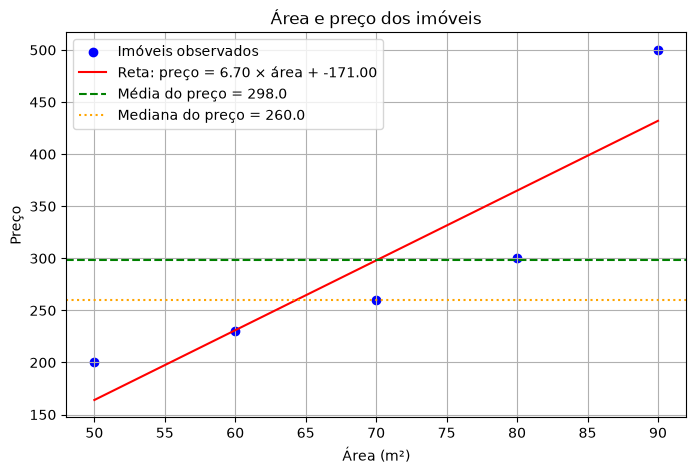

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Coeficientes da reta: preco = a * area + b
a, b = np.polyfit(imoveis["area"], imoveis["preco"], deg=1)

# Estatísticas dos preços
media_preco = imoveis["preco"].mean()
mediana_preco = imoveis["preco"].median()

# Pontos da reta para desenhar a linha
areas_linha = np.linspace(imoveis["area"].min(), imoveis["area"].max(), 100)
precos_linha = a * areas_linha + b

# Gráfico
plt.figure(figsize=(8, 5))

# Imóveis observados
plt.scatter(
    imoveis["area"],
    imoveis["preco"],
    color="blue",
    label="Imóveis observados"
)

# Reta ajustada
plt.plot(
    areas_linha,
    precos_linha,
    color="red",
    label=f"Reta: preço = {a:.2f} × área + {b:.2f}"
)

# Média e mediana dos preços
plt.axhline(
    media_preco,
    color="green",
    linestyle="--",
    label=f"Média do preço = {media_preco:.1f}"
)

plt.axhline(
    mediana_preco,
    color="orange",
    linestyle=":",
    label=f"Mediana do preço = {mediana_preco:.1f}"
)

plt.xlabel("Área (m²)")
plt.ylabel("Preço")
plt.title("Área e preço dos imóveis")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
# Imports essenciais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Configuração estática para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# 1. Criação do Dataset Fictício
def carregar_dados():
    np.random.seed(42)
    # Criando 50 clientes com idade e gasto anual fortemente correlacionados
    idade = np.random.randint(20, 65, size=50)
    gasto_anual = (idade * 150) + np.random.normal(0, 500, size=50) # Relação direta + ruído
    
    df = pd.DataFrame({
        'Idade': idade,
        'Gasto_Anual_RS': gasto_anual
    })
    return df

df_original = carregar_dados()
print("--- Primeiras 5 linhas dos Dados Originais ---")
print(df_original.head())

--- Primeiras 5 linhas dos Dados Originais ---
   Idade  Gasto_Anual_RS
0     58     8189.223903
1     48     7119.122307
2     34     4833.175598
3     62     9297.236069
4     27     3935.274773


In [26]:
def processar_pca(df):
    # Etapa A: Padronização
    scaler = StandardScaler()
    dados_padronizados = scaler.fit_transform(df)
    
    # Etapa B: Aplicação do PCA para 2 componentes
    pca = PCA(n_components=2)
    componentes_pca = pca.fit_transform(dados_padronizados)
    
    # DataFrames organizados para comparação
    df_scaled = pd.DataFrame(dados_padronizados, columns=['Idade_Padronizada', 'Gasto_Padronizado'])
    
    df_pca = pd.DataFrame(componentes_pca, columns=['PC1', 'PC2'])
    
    return scaler, pca, df_scaled, df_pca

scaler, pca, df_scaled, df_pca = processar_pca(df_original)

# Impressão comparativa tabular para os alunos
print("="*60)
print(" COMPARATIVO DOS DADOS (Primeiras 5 amostras)")
print("="*60)
df_comparativo = pd.concat([df_original.head(), df_scaled.head(), df_pca.head()], axis=1)
print(df_comparativo.to_string())
print("="*60)

 COMPARATIVO DOS DADOS (Primeiras 5 amostras)
   Idade  Gasto_Anual_RS  Idade_Padronizada  Gasto_Padronizado       PC1       PC2
0     58     8189.223903           1.276951           0.951346  1.575644 -0.230237
1     48     7119.122307           0.490651           0.412883  0.638895 -0.054990
2     34     4833.175598          -0.610168          -0.737380 -0.952861 -0.089952
3     62     9297.236069           1.591470           1.508886  2.192283 -0.058396
4     27     3935.274773          -1.160578          -1.189194 -1.661540 -0.020234


In [27]:
# Exibindo quanta informação cada componente retém
variancia_explicada = pca.explained_variance_ratio_

print("--- RELATÓRIO DE RETENÇÃO DE INFORMAÇÃO (PCA) ---")
print(f"Variância explicada pelo PC1: {variancia_explicada[0]*100:.2f}%")
print(f"Variância explicada pelo PC2: {variancia_explicada[1]*100:.2f}%")
print(f"Total de informação mantida:  {np.sum(variancia_explicada)*100:.2f}%")
print("-" * 50)
print("Interpretação para a aula:")
print(f"Se descartarmos o PC2 e mantivermos apenas 1 dimensão (PC1),")
print(f"preservaremos {variancia_explicada[0]*100:.2f}% de toda a informação original.")

--- RELATÓRIO DE RETENÇÃO DE INFORMAÇÃO (PCA) ---
Variância explicada pelo PC1: 98.20%
Variância explicada pelo PC2: 1.80%
Total de informação mantida:  100.00%
--------------------------------------------------
Interpretação para a aula:
Se descartarmos o PC2 e mantivermos apenas 1 dimensão (PC1),
preservaremos 98.20% de toda a informação original.


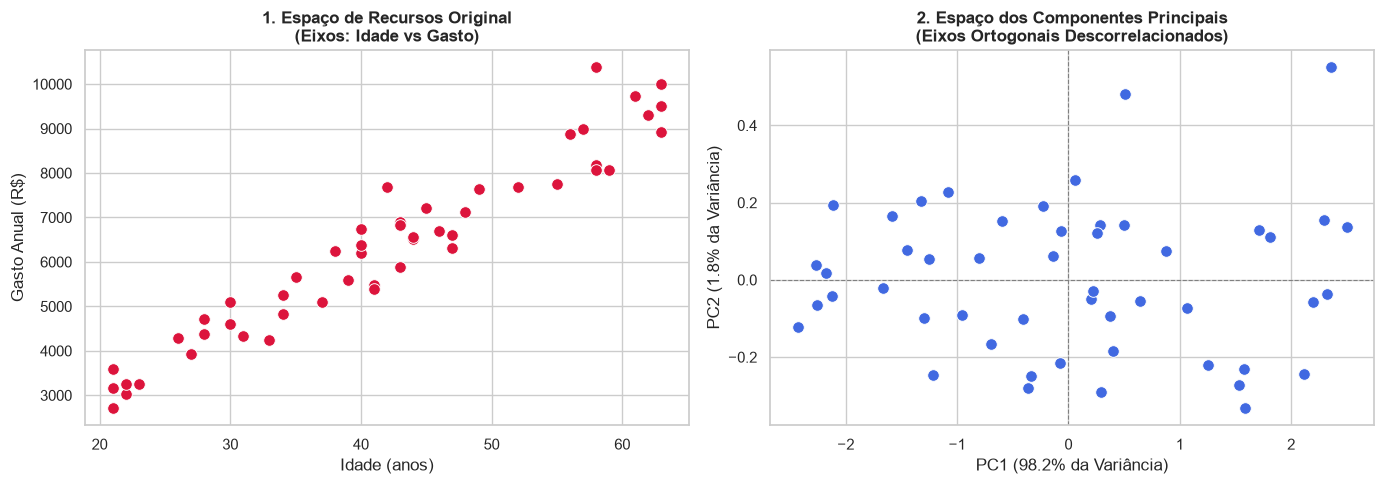

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Espaço Original
sns.scatterplot(
    ax=axes[0], 
    data=df_original, 
    x='Idade', 
    y='Gasto_Anual_RS', 
    color='crimson', 
    s=70
)
axes[0].set_title("1. Espaço de Recursos Original\n(Eixos: Idade vs Gasto)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Idade (anos)")
axes[0].set_ylabel("Gasto Anual (R$)")

# Gráfico 2: Espaço Transformado (PCA)
sns.scatterplot(
    ax=axes[1], 
    data=df_pca, 
    x='PC1', 
    y='PC2', 
    color='royalblue', 
    s=70
)
axes[1].axhline(0, color='grey', linestyle='--', linewidth=0.8)
axes[1].axvline(0, color='grey', linestyle='--', linewidth=0.8)
axes[1].set_title("2. Espaço dos Componentes Principais\n(Eixos Ortogonais Descorrelacionados)", fontsize=12, fontweight='bold')
axes[1].set_xlabel(f"PC1 ({variancia_explicada[0]*100:.1f}% da Variância)")
axes[1].set_ylabel(f"PC2 ({variancia_explicada[1]*100:.1f}% da Variância)")

plt.tight_layout()
plt.show()